In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# **NATURAL LANGUAGE PROCESSING**
# Vectorization of Natural Language

Natural Language Processing (NLP) is a technology that allows computers to process the natural language that humans use on a daily basis .
Here, we will consider using natural language as input for machine learning.

Many machine learning methods assume that numerical data (quantitative variables) are input, so it is necessary to convert natural language text data into numerical data. This is called vectorization of natural language. Various methods have been devised to effectively capture the Characteristics of text data during vectorization, and we will learn about them in this Sprint.

# Unstructured Data
When categorizing data, structured data is data that is easy for computers to handle, such as numbers summarized in a table, while unstructured data is data that is easy for humans to handle, such as images, videos, text, and audio .
Vectorization of natural language can be said to be the process of converting unstructured data into structured data.
Even with the same unstructured data, this conversion process was not very necessary when using deep learning for images, but how to do this with text is important.

# What can natural language processing do?
Using natural language text as input and output for machine learning makes many things possible. Machine translation is an example where both the input and output are text, and has been put to practical use. Research is also underway on image caption generation, where the input is an image and the output is text , and the reverse - image generation from text.

However, it is difficult to output unstructured data such as text or images.
A relatively easy method is text classification, where the input is text and the output is a category .

A classic example of sentiment analysis, like fleur-de-lis, Titanic, and handwritten digits, is the sentiment analysis of the IMDB movie reviews dataset. We classify review documents into binary categories, whether they are positive or negative about the movie. Each document is given a label for positive or negative,and we will use this in this text.

# Preparing the IMDB Movie Reviews Dataset

In [2]:
# download using wget command
# Download MDB to current folder
!wget http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
# Unzip
!tar zxf aclImdb_v1.tar.gz
# aclImdb/train/unsup is deleted because it is unlabeled
!rm -rf aclImdb/train/unsup
# Show description of IMDB dataset
!cat aclImdb/README

--2025-04-27 16:30:49--  http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  10.1MB/s    in 18s     

2025-04-27 16:31:07 (4.40 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]

Large Movie Review Dataset v1.0

Overview

This dataset contains movie reviews along with their associated binary
sentiment polarity labels. It is intended to serve as a benchmark for
sentiment classification. This document outlines how the dataset was
gathered, and how to use the files provided. 

Dataset 

The core dataset contains 50,000 reviews split evenly into 25k train
and 25k test sets. The overall distribution of labels is balanced (25k
pos and 25k neg). We also include an a

In [3]:
# Import
from sklearn.datasets import load_files

train_review = load_files('./aclImdb/train/', encoding='utf-8')
x_train, y_train = train_review.data, train_review.target

test_review = load_files('./aclImdb/test/', encoding='utf-8')
x_test, y_test = test_review.data, test_review.target

# Display the correspondence between labels 0,1 and meanings
print(train_review.target_names)

['neg', 'pos']


In [4]:
# About this dataset
print("x : {}".format(x_train[0]))

x : Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty.


IMDd site allows users to post comments and ratings for movies on a scale of 1 to 10.
From the database, we create a training dataset with 25,000 entries and a test dataset with 25,000 entries.

Reviews are labeled with a binary value, with reviews below 4 being negative and below 7 being positive, and this allows for classification of emotions.
Neutral reviews with a score of 5 or 6 are not included in the dataset.
In addition, the labels are uniform for both training and testing.

# Classic Method
1. BoW (Bag of Words) - This is a method that counts the number of times a word appears in each sample and creates a vector. Words are treated as categories and expressed as one-hot.

Example: first 5 words of three sentences.

In [5]:
mini_dataset = \
  ["This movie is very good.",
  "This film is a good",
  "Very bad. Very, very bad."]

In [6]:
# Apply BoW using scikit-learn’s CountVectorizer
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w+\b')
bow = (vectorizer.fit_transform(mini_dataset)).toarray()

# DataFrameにまとめる
df = pd.DataFrame(bow, columns=vectorizer.get_feature_names_out())
display(df)

,a,bad,film,good,is,movie,this,very
0,0,0,0,1,1,1,1,1
1,1,0,1,1,1,0,1,0
2,0,2,0,0,0,0,0,3


The eight different words that appear in the three example sentences are the column names, and the number of times they appear in samples 0, 1, and 2 is shown. In the second sample, "Very bad. Very, very bad," "bad" appears twice and "very" appears three times. The words that are the column names are called the vocabulary of the dataset.

With BoW, each text sample becomes a feature with the dimension of the vocabulary size, which can then be input to a machine learning model.
The entire text used at this time is called a corpus. The vocabulary is determined by the words contained in the corpus, and the model is trained using these as features.
Therefore, vocabulary that appears for the first time in the test data is ignored when vectorizing.

# Pretreatment
The CountVectorizer class automatically performs preprocessing such as converting uppercase letters to lowercase. This type of preprocessing is important in natural language processing, and it is common to perform other preprocessing such as removing unnecessary symbols ( text cleaning ) and standardizing spelling variations separately.

We may also use a process called stemming to align words whose forms change, such as "see," "saw," and "seen," to their roots .

# Token
BoW does not strictly count words, but rather counts chunks defined as tokens. What is considered as a token is specified by an argument in CountVectorizer using regular expression syntax. token_patternThe default
is r'(?u)\b\w\w+\b', but in the above example r'(?u)\b\w+\b'it is .

By default, two or more characters surrounded by spaces, punctuation marks, slashes, etc. are extracted as one token, so letters such as "a" and "I" are not counted. In English, one-letter words do not express much of the characteristics of a sentence, so they are sometimes excluded.
However, in the above example, an argument is specified so that one-letter words are also extracted as tokens.

# Morphological analysis
In many languages, such as English, tokenization can be done based on an obvious criterion: whitespace, but this is not possible in Japanese.

In Japanese, we divide words into parts of speech such as nouns, particles, and verbs . For example, the Japanese sentence "I learn programming" becomes "I/wa/programming/wo/learn/masu."

For this, we use morphological analysis tools such as MeCab and Janome . They can also be used from Python. The National Institute for Japanese Language and Linguistics also provides a service called Web Chamame , which allows you to easily use MeCab on the web.

In natural language, new words are born every day, so it is important to be able to handle them. mecab-ipadic-NEologd is an open source dictionary for MeCab that is updated weekly.

# n-gram
In the BoW example above, we counted the number of times each word (token) appeared, but this did not take word order into account at all.

To take this into account, the idea of n-grams , which groups adjacent words together, is sometimes applied. When two words are grouped together, it is called a 2-gram (bigram) , and looks like this:

In [7]:
# Specify the n-gram range to use with ngram_range
vectorizer = CountVectorizer(ngram_range=(2, 2), token_pattern=r'(?u)\b\w+\b')
bow_train = (vectorizer.fit_transform(mini_dataset)).toarray()
df = pd.DataFrame(bow_train, columns=vectorizer.get_feature_names_out())
display(df)

,a good,bad very,film is,is a,is very,movie is,this film,this movie,very bad,very good,very very
0,0,0,0,0,1,1,0,1,0,1,0
1,1,0,1,1,0,0,1,0,0,0,0
2,0,1,0,0,0,0,0,0,2,0,1


The 2-gram counts "very good" and "very bad" separately.

If words are not grouped together, it is called a 1-gram (unigram) . Any number of words can be considered, such as a 3-gram (trigram) that groups three words together. BoW can also be performed by combining 1-grams and 2-grams.

# Problem 1: Scratch implementation of BoW
We create a program that can calculate the BoW of the following three sentences without using scikit-learn. Calculate using 1-gram and 2-gram.
- This movie is SOOOO funny!!!
- What a movie! I never
- best movie ever!!!!! this movie



In [8]:
import re
from collections import Counter
# Preprocessing
def preprocess (text):
    text = text.lower() # !capital letters
    text = re.sub(r'[^\w\s]', '', text) # !punctuation
    return text

# Tokenization
def generate_ngrams(text,n):
    words = text.split() # split text to words
    ngrams = zip(*[words[i:] for i in range(n)]) # create grams
    return [' '.join(ngram) for ngram in ngrams] # join to strings
# Create BoW
def bag_of_words(sentences, n):
    bow = Counter()  # hold the n-gram counts
    for sentence in sentences:
        cleaned_sentence = preprocess(sentence)  # preprocess the sentence
        ngrams = generate_ngrams(cleaned_sentence, n)  # generate n-grams
        bow.update(ngrams)  # update the counts
    return bow

In [9]:
# dataset
sentences = [
    "This movie is SOOOO funny!!!",
    "What a movie! I never",
    "best movie ever!!!!! this movie"
]

# 1-gram
unigrams = bag_of_words(sentences, 1)
print("1-grams (unigrams):")
print(unigrams)

# 2-grams
bigrams = bag_of_words(sentences, 2)
print("\n2-grams (bigrams):")
print(bigrams)

1-grams (unigrams):
Counter({'movie': 4, 'this': 2, 'is': 1, 'soooo': 1, 'funny': 1, 'what': 1, 'a': 1, 'i': 1, 'never': 1, 'best': 1, 'ever': 1})

2-grams (bigrams):
Counter({'this movie': 2, 'movie is': 1, 'is soooo': 1, 'soooo funny': 1, 'what a': 1, 'a movie': 1, 'movie i': 1, 'i never': 1, 'best movie': 1, 'movie ever': 1, 'ever this': 1})


2. TF-IDF - is an extension of BoW which is a combination of two metrics: Term Frequency (TF) and Inverse Document Frequency (IDF).


The IDF is an index whose value increases the more rare a token is in a dataset. If we set the number of samples $N$ to 25,000, which is the same as the training data for the IMDB movie review dataset, and look at the graph where we change the number of samples in which a token appears, $df(t)$, we get the following:

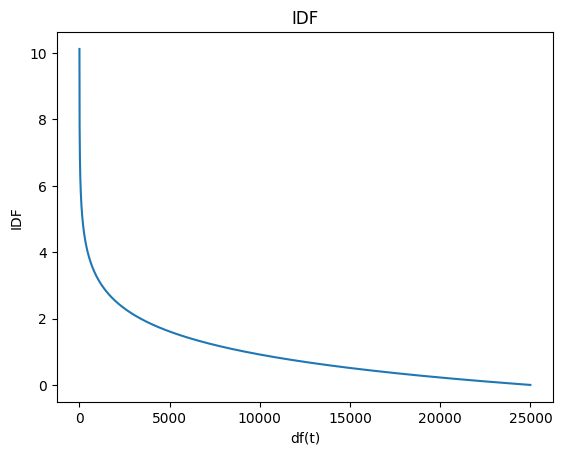

In [10]:
import numpy as np
import matplotlib.pyplot as plt
n_samples = 25000
idf = np.log(n_samples/np.arange(1,n_samples))
plt.title("IDF")
plt.xlabel("df(t)")
plt.ylabel("IDF")
plt.plot(idf)
plt.show()

- Stop words - Tokens that appear too frequently can be preprocessed by not only reducing their value but also removing them. These are called stop words . This can be done using a list of existing stop words or by using a threshold.


In [11]:
vectorizer = CountVectorizer(stop_words=["is"], token_pattern=r'\b\w+\b')
bow_train = (vectorizer.fit_transform(mini_dataset)).toarray()
df = pd.DataFrame(bow_train, columns=vectorizer.get_feature_names_out())
display(df)

,a,bad,film,good,movie,this,very
0,0,0,0,1,1,1,1
1,1,0,1,1,0,1,0
2,0,2,0,0,0,0,3


A representative existing stop word list is that of the natural language processing library NLTK . It is advisable to check the contents before using it, since it may contain words that are particularly important for a certain dataset.

In [12]:
# Download stop words if you are using for the first time
import nltk
stop_words = nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = stopwords.words('english')
print("stop word : {}".format(stop_words)) # 'i', 'me', 'my', ...

stop word : ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Conversely, tokens that appear infrequently are often removed because using all tokens would significantly increase the dimensionality of the vector, increasing computational costs.

scikit-learn's CountVectorizer allows you to specify the maximum number of terms in the argument max_features. In the following example, the 5 most frequently occurring terms are vectorized.

In [13]:
vectorizer = CountVectorizer(token_pattern=r'\b\w+\b', max_features = 5)
bow_train = (vectorizer.fit_transform(mini_dataset)).toarray()
df = pd.DataFrame(bow_train, columns=vectorizer.get_feature_names_out())
display(df)

,bad,good,is,this,very
0,0,1,1,1,1
1,0,1,1,1,0
2,2,0,0,0,3


# Problem 2: Calculating TF-IDF
Vectorize the IMDB movie reviews dataset using TF-IDF. Use NLTK stop words and set the maximum vocabulary size to around 5000. This problem does not require preprocessing such as text cleaning or stemming.

To calculate TF-IDF, use one of the scikit-learn classes:

In [14]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

# Ensure that stopwords are downloaded
nltk.download('stopwords')

# Use NLTK stopwords for English
stop_words = stopwords.words('english')

# Initialize TfidfVectorizer with NLTK stop words and max features set to 5000
vectorizer = TfidfVectorizer(stop_words=stop_words, max_features=5000)

# Fit and transform the training data to get TF-IDF representation
X_train_tfidf = vectorizer.fit_transform(x_train)

# Convert to DataFrame for better visualization
tfidf_train_df = pd.DataFrame(X_train_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

# Show the first few rows of the TF-IDF DataFrame
print(tfidf_train_df.head())

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


    00  000        10  100   11   12   13  13th        14   15  ...  yet  \
0  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0  0.000000  0.0  ...  0.0   
1  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0  0.000000  0.0  ...  0.0   
2  0.0  0.0  0.127480  0.0  0.0  0.0  0.0   0.0  0.000000  0.0  ...  0.0   
3  0.0  0.0  0.085006  0.0  0.0  0.0  0.0   0.0  0.000000  0.0  ...  0.0   
4  0.0  0.0  0.000000  0.0  0.0  0.0  0.0   0.0  0.104143  0.0  ...  0.0   

   york     young  younger  youth      zero  zizek  zombie  zombies  zone  
0   0.0  0.164505      0.0    0.0  0.136932    0.0     0.0      0.0   0.0  
1   0.0  0.000000      0.0    0.0  0.000000    0.0     0.0      0.0   0.0  
2   0.0  0.000000      0.0    0.0  0.000000    0.0     0.0      0.0   0.0  
3   0.0  0.000000      0.0    0.0  0.000000    0.0     0.0      0.0   0.0  
4   0.0  0.000000      0.0    0.0  0.000000    0.0     0.0      0.0   0.0  

[5 rows x 5000 columns]


# Problem 3: Learning using TF-IDF
Use the vectors obtained in Problem 2 to train and estimate the IMDB movie review dataset. Use any model that can perform binary classification. We try changing the maximum vocabulary size, stop words, and number of n-grams to see what affects it.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = stopwords.words('english')

# TF-IDF Configuration
def train_tfidf_model(ngram_range=(1, 1), max_features=5000, use_stop_words=True):
    # Use the TfidfVectorizer to convert text to IT-IDF
    vectorizer = TfidfVectorizer(max_features=max_features, 
                                 stop_words=stop_words if use_stop_words else None,
                                 ngram_range=ngram_range)

    # Fit and transform the training data
    X_train_tfidf = vectorizer.fit_transform(x_train)
    X_test_tfidf = vectorizer.transform(x_test)
    
    # Split the dataset for training and validation
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_tfidf, y_train, test_size=0.2, random_state=42)

    # Train a Logistic Regression model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_split, y_train_split)

    # Evaluate the model on the validation set
    y_pred = model.predict(X_val_split)
    print("Logistic Regression Results:")
    print("Accuracy:", accuracy_score(y_val_split, y_pred))
    print("Classification Report:\n", classification_report(y_val_split, y_pred))

    # Train and evaluate an SVM model for comparison
    svm_model = SVC(kernel='linear')
    svm_model.fit(X_train_split, y_train_split)
    y_pred_svm = svm_model.predict(X_val_split)
    print("SVM Results:")
    print("Accuracy:", accuracy_score(y_val_split, y_pred_svm))
    print("Classification Report:\n", classification_report(y_val_split, y_pred_svm))

# Experiment with different configurations
print("Training with Unigrams, Max Features = 5000, Stop Words = True:")
train_tfidf_model(ngram_range=(1, 1), max_features=5000, use_stop_words=True)

print("\nTraining with Bigrams, Max Features = 5000, Stop Words = True:")
train_tfidf_model(ngram_range=(2, 2), max_features=5000, use_stop_words=True)

print("\nTraining with Unigrams, Max Features = 1000, Stop Words = False:")
train_tfidf_model(ngram_range=(1, 1), max_features=1000, use_stop_words=False)

print("\nTraining with Bigrams, Max Features = 1000, Stop Words = False:")
train_tfidf_model(ngram_range=(2, 2), max_features=1000, use_stop_words=False)

Training with Unigrams, Max Features = 5000, Stop Words = True:


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Logistic Regression Results:
Accuracy: 0.8748
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      2482
           1       0.87      0.88      0.88      2518

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

SVM Results:
Accuracy: 0.877
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.88      2482
           1       0.87      0.88      0.88      2518

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000


Training with Bigrams, Max Features = 5000, Stop Words = True:
Logistic Regression Results:
Accuracy: 0.8186
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.81 

# Problem 4: Scratch implementation of TF-IDF
We create a program that can calculate the TF-IDF of the following three sentences without using scikit-learn. We create two types: the standard formula and the formula used by scikit-learn. Normalization is not necessary.

This movie is SOOOO funny!!!
What a movie! I never
best movie ever!!!!! this movie

In [16]:
import math
from collections import Counter

# Input sentences
minidataset = [
    "This movie is SOOOO funny!!!",
    "What a movie! I never",
    "best movie ever!!!!! this movie"
]

# Preprocess: Remove punctuation and convert to lowercase
def preprocess(text):
    # Remove punctuation and convert to lowercase
    text = text.lower()
    text = ''.join([char if char.isalnum() or char.isspace() else ' ' for char in text])
    return text

# Apply preprocessing to all sentences in the minidataset
minidataset = [preprocess(doc) for doc in minidataset]

# Tokenize sentences into words
tokens = [doc.split() for doc in minidataset]

# Calculate term frequency (TF)
def compute_tf(doc):
    tf = Counter(doc)
    total_terms = len(doc)
    for term in tf:
        tf[term] /= total_terms  # Normalize by document length
    return tf

# Calculate inverse document frequency (IDF) using the standard formula
def compute_idf(minidataset, vocabulary):
    N = len(minidataset)
    idf = {}
    for term in vocabulary:
        df = sum(1 for doc in minidataset if term in doc)
        idf[term] = math.log((N + 1) / (df + 1))  # Standard IDF formula
    return idf

# Compute IDF using scikit-learn's formula
def compute_idf_sklearn(minidataset, vocabulary):
    N = len(minidataset)
    idf = {}
    for term in vocabulary:
        df = sum(1 for doc in minidataset if term in doc)
        idf[term] = (math.log((1 + N) / (df + 1)) + 1)  # Scikit-learn's IDF formula
    return idf

# Calculate TF-IDF using standard formula
def compute_tfidf(minidataset, standard=True):
    # Create vocabulary (unique terms across all documents)
    vocabulary = set(term for doc in tokens for term in doc)

    # Compute TF for all documents
    tf_values = [compute_tf(doc) for doc in tokens]

    # Compute IDF for all terms in the minidataset
    if standard:
        idf_values = compute_idf(minidataset, vocabulary)
    else:
        idf_values = compute_idf_sklearn(minidataset, vocabulary)

    # Compute TF-IDF by multiplying TF and IDF for each term in each document
    tfidf_values = []
    for doc_idx, doc in enumerate(tokens):
        tfidf_doc = {}
        for term in doc:
            tfidf_doc[term] = tf_values[doc_idx][term] * idf_values[term]
        tfidf_values.append(tfidf_doc)

    return tfidf_values

# Compute TF-IDF for both standard and scikit-learn formula
tfidf_standard = compute_tfidf(minidataset, standard=True)
tfidf_sklearn = compute_tfidf(minidataset, standard=False)

# Output the results
print("TF-IDF (Standard Formula):")
for i, doc_tfidf in enumerate(tfidf_standard):
    print(f"\nDocument {i + 1}:")
    for term, value in doc_tfidf.items():
        print(f"Term: {term}, TF-IDF: {value:.4f}")

print("\nTF-IDF (Scikit-learn Formula):")
for i, doc_tfidf in enumerate(tfidf_sklearn):
    print(f"\nDocument {i + 1}:")
    for term, value in doc_tfidf.items():
        print(f"Term: {term}, TF-IDF: {value:.4f}")

TF-IDF (Standard Formula):

Document 1:
Term: this, TF-IDF: 0.0575
Term: movie, TF-IDF: 0.0000
Term: is, TF-IDF: 0.0575
Term: soooo, TF-IDF: 0.1386
Term: funny, TF-IDF: 0.1386

Document 2:
Term: what, TF-IDF: 0.1386
Term: a, TF-IDF: 0.1386
Term: movie, TF-IDF: 0.0000
Term: i, TF-IDF: 0.0000
Term: never, TF-IDF: 0.1386

Document 3:
Term: best, TF-IDF: 0.1386
Term: movie, TF-IDF: 0.0000
Term: ever, TF-IDF: 0.0575
Term: this, TF-IDF: 0.0575

TF-IDF (Scikit-learn Formula):

Document 1:
Term: this, TF-IDF: 0.2575
Term: movie, TF-IDF: 0.2000
Term: is, TF-IDF: 0.2575
Term: soooo, TF-IDF: 0.3386
Term: funny, TF-IDF: 0.3386

Document 2:
Term: what, TF-IDF: 0.3386
Term: a, TF-IDF: 0.3386
Term: movie, TF-IDF: 0.2000
Term: i, TF-IDF: 0.2000
Term: never, TF-IDF: 0.3386

Document 3:
Term: best, TF-IDF: 0.3386
Term: movie, TF-IDF: 0.4000
Term: ever, TF-IDF: 0.2575
Term: this, TF-IDF: 0.2575


# Word2Vec
Word2Vec is a method of vectorization using neural networks. BoW and TF-IDF are one-hot representations, so the dimension of the resulting vector is the same as the vocabulary. This makes it difficult to increase the vocabulary size. On the other hand, Word2Vec converts words into vectors of any dimension. This is called word embedding or distributed representation . The conversion operation is often referred to as "embedding into a vector space."

Word2Vec has two mechanisms:
1. CBoW - Continuous Bag-of-Words trains a two-layer fully connected neural network to predict words that come between two other words.
2. Skip-gram - a method of training a two-layered fully connected neural network to predict the words before and after a given word, which is the opposite of CBoW .

Let's try learning the same sentence as the BoW example. Unlike CountVectorizer, it does not automatically perform preprocessing, so we split the words (tokens) into a list. We also align uppercase letters to lowercase and remove symbols.

The default parameters are calculated using CBoW, and the window size window=5is set to.

In [17]:
from gensim.models import Word2Vec

# Example sentences
sentences = [['this', 'movie', 'is', 'very', 'good'], 
             ['this', 'film', 'is', 'a', 'good'], 
             ['very', 'bad', 'very', 'very', 'bad']]

# Create and train the Word2Vec model
model = Word2Vec(sentences, min_count=1, vector_size=10, epochs=10) # Use vector_size instead of size

# Build the vocabulary and train the model
model.build_vocab(sentences)
model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)

# Print the vocabulary
print("Vocabulary list: {}".format(list(model.wv.key_to_index.keys())))

# Print word vectors
for vocab in model.wv.key_to_index.keys():
    print("{} Vector of: \n{}".format(vocab, model.wv[vocab]))

Vocabulary list: ['very', 'bad', 'good', 'is', 'this', 'a', 'film', 'movie']
very Vector of: 
[-0.07509569 -0.00931358  0.09540854 -0.07318459 -0.02333888 -0.01937773
  0.08079815 -0.05933649  0.00043907 -0.04756326]
bad Vector of: 
[ 0.05455794  0.08345953 -0.01453741 -0.09208143  0.04370552  0.00571785
  0.07441908 -0.00813283 -0.02638414 -0.08753009]
good Vector of: 
[-0.0960355   0.05007293 -0.08759586 -0.04391825 -0.000351   -0.00296181
 -0.0766124   0.09614743  0.04982058  0.09233143]
is Vector of: 
[ 0.07311065  0.05070519  0.06759309  0.00761263  0.06350898 -0.03405724
 -0.0094533   0.05768519 -0.07522386 -0.03936936]
this Vector of: 
[-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]
a Vector of: 
[-0.01577198  0.00321244 -0.04143998 -0.07683337 -0.01508437  0.0247105
 -0.00889703  0.05535757 -0.02743117  0.02261837]
film Vector of: 
[-0.08157917  0.04495798 -0.04137076  0.00824536  0.08498619 -0.04462177


Word distance - By performing computations across vectors, we can find words that have vectors similar to a word, for example finding three words with vectors similar to good.

In [18]:
model.wv.most_similar(positive="good", topn=3)

[('a', 0.6145167350769043),
 ('film', 0.24953827261924744),
 ('this', -0.22418653964996338)]

In the current example, only three sentences are trained, so it is not very effective, but by training on a larger corpus, interesting results can be obtained, such as parallel sentences coming closer together.

# Visualization
By compressing it into two dimensions, we can visualize the relative positions of each word. Below is an example using t-SNE.

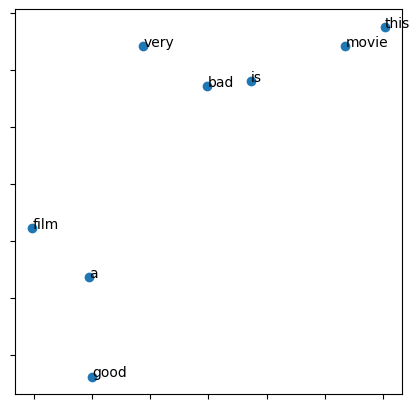

In [19]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Get the vocabulary keys
vocabs = list(model.wv.key_to_index.keys())  # Use 'key_to_index' instead of 'vocab'

# Get the word vectors for the vocabulary
vectors = [model.wv[word] for word in vocabs]

# Convert the list of vectors to a NumPy array
vectors = np.array(vectors)

# Perform t-SNE dimensionality reduction
tsne_model = TSNE(perplexity=2, n_components=2, init="pca", n_iter=5000, random_state=23)
vectors_tsne = tsne_model.fit_transform(vectors)

# Plot the results
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1])

# Annotate the points with the corresponding words
for i, word in enumerate(vocabs):
    plt.annotate(word, xy=(vectors_tsne[i, 0], vectors_tsne[i, 1]))

# Clean up the axes
ax.set_yticklabels([])
ax.set_xticklabels([])

# Show the plot
plt.show()

# Distributed Representation of the IMDB Movie Reviews Dataset
Let's train Word2Vec using the training data from the IMDB movie reviews dataset as a corpus to obtain distributed representations.

# Problem 5: Corpus preprocessing
We pre-process the corpus by removing special characters (such as !), URLs, converting uppercase to lowercase, etc. Also, split the words (tokens) into a list.

In [20]:
import re
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')

def preprocess_corpus(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize the text into words
    words = word_tokenize(text)
    
    return words

# Example usage
sample_text = [
    "This movie is great! I loved it!",
    "What a waste of time, don't bother watching.",
    "An excellent film, totally worth watching!"
]
processed_corpus = [preprocess_corpus(review) for review in sample_text]
print(processed_corpus)

[['this', 'movie', 'is', 'great', 'i', 'loved', 'it'], ['what', 'a', 'waste', 'of', 'time', 'dont', 'bother', 'watching'], ['an', 'excellent', 'film', 'totally', 'worth', 'watching']]


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Problem 6: Learning Word2Vec
We train Word2Vec.

In [21]:
from gensim.models import Word2Vec

# Train Word2Vec model
model = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, min_count=1, sg=0)  # SG=0 for CBOW, 1 for Skip-gram

# Save the model
model.save("imdb_word2vec.model")

# Example: Check vocabulary
print("Vocabulary:", list(model.wv.index_to_key))

# Get the vector for a word (e.g., 'movie')
vector_movie = model.wv['movie']
print("Vector for 'movie':", vector_movie)


Vocabulary: ['watching', 'worth', 'a', 'movie', 'is', 'great', 'i', 'loved', 'it', 'what', 'waste', 'totally', 'of', 'time', 'dont', 'bother', 'an', 'excellent', 'film', 'this']
Vector for 'movie': [-8.2426779e-03  9.2993546e-03 -1.9766092e-04 -1.9672764e-03
  4.6036304e-03 -4.0953159e-03  2.7431143e-03  6.9399667e-03
  6.0654259e-03 -7.5107943e-03  9.3823504e-03  4.6718083e-03
  3.9661205e-03 -6.2435055e-03  8.4599797e-03 -2.1501649e-03
  8.8251876e-03 -5.3620026e-03 -8.1294188e-03  6.8245591e-03
  1.6711927e-03 -2.1985089e-03  9.5136007e-03  9.4938548e-03
 -9.7740470e-03  2.5052286e-03  6.1566923e-03  3.8724565e-03
  2.0227872e-03  4.3050171e-04  6.7363144e-04 -3.8206363e-03
 -7.1402504e-03 -2.0888723e-03  3.9238976e-03  8.8186832e-03
  9.2591504e-03 -5.9759365e-03 -9.4026709e-03  9.7643770e-03
  3.4297847e-03  5.1661171e-03  6.2823449e-03 -2.8042626e-03
  7.3227035e-03  2.8302716e-03  2.8710044e-03 -2.3803699e-03
 -3.1282497e-03 -2.3701417e-03  4.2764368e-03  7.6057913e-05
 -9.58427

# Problem 7: (Advanced) Vector visualization
Visualize the resulting vectors using t-SNE, and pick some words to wv.most_similarfind similar words using

Trained Vector
The vectors obtained by training on a large corpus are also publicly available, so you can use them without training them yourself. In addition to the original Word2Vec, there are also FastText and GloVe from Stanford University, which are both developed by the same author , and each of them is publicly available.

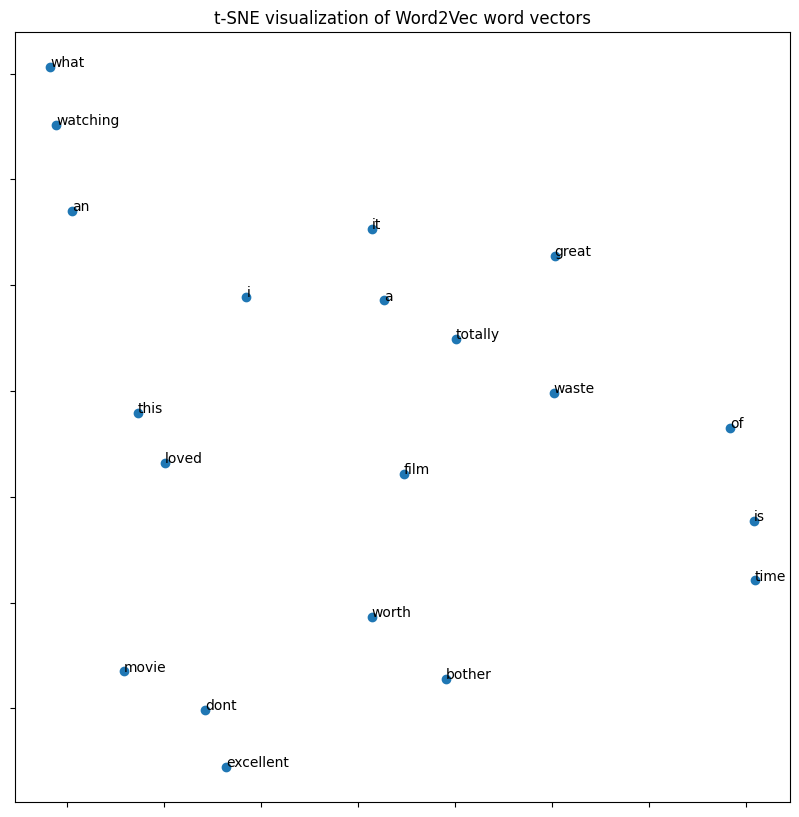

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Get the vectors for a subset of words
words = list(model.wv.index_to_key)[:50]
vectors = np.array([model.wv[word] for word in words])  # Convert list of vectors to a NumPy array

# Perform t-SNE dimensionality reduction
tsne_model = TSNE(perplexity=3, n_components=2, init="pca", n_iter=3000, random_state=23)
vectors_tsne = tsne_model.fit_transform(vectors)

# Visualize
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(vectors_tsne[:, 0], vectors_tsne[:, 1])

for i, word in enumerate(words):
    ax.annotate(word, xy=(vectors_tsne[i, 0], vectors_tsne[i, 1]))

ax.set_yticklabels([])
ax.set_xticklabels([])
plt.title("t-SNE visualization of Word2Vec word vectors")
plt.show()

# Problem 8: (Advanced Task) Movie review classification using Word2Vec
Use the vectors obtained in Problem 6 or publicly available trained vectors to train and estimate sentiment classification for the IMDB movie review dataset.

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_files
from gensim.models import Word2Vec

# Load the dataset
train_review = load_files('./aclImdb/train/', encoding='utf-8')
x_train, y_train = train_review.data, train_review.target
test_review = load_files('./aclImdb/test/', encoding='utf-8')
x_test, y_test = test_review.data, test_review.target

def preprocess_review(review):
    review = review.lower().split()
    return review

# Process the corpus
processed_corpus = [preprocess_review(review) for review in x_train]

# Train Word2Vec model
model = Word2Vec(sentences=processed_corpus, vector_size=100, window=5, min_count=1, sg=0)  # SG=0 for CBOW

# Create vectors for each review by averaging word vectors
def get_review_vector(review):
    review_vector = np.zeros(100)
    num_words = 0
    for word in review:
        if word in model.wv:
            review_vector += model.wv[word]
            num_words += 1
    if num_words > 0:
        review_vector /= num_words  # Average the word vectors
    return review_vector

# Convert the entire training and test datasets into vectors
X_train_vec = np.array([get_review_vector(review) for review in processed_corpus])
X_test_vec = np.array([get_review_vector(preprocess_review(review)) for review in x_test])

# Train a logistic regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_vec, y_train)

# Evaluate the model
accuracy = clf.score(X_test_vec, y_test)
print("Accuracy on test set:", accuracy)


Accuracy on test set: 0.80464


An accuracy of 80.45% shows that the Word2Vec embeddings are helping to capture meaningful relationships in the text and that the logistic regression classifier is doing a good job of distinguishing between positive and negative reviews.